In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [3]:
no_plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_20cm.csv")
plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_20cm.csv")
no_plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_30cm.csv")
plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_30cm.csv")

In [4]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [5]:
f_20 = no_plates_20["frequency"].unique()
f_30 = no_plates_30["frequency"].unique()

D_20 = 0.2
H_20 = 0.15
D_30 = 0.3
H_30 = 0.25

k_20 = []
for f in f_20:
    k_20.append(wave_number_in_theory(f, H_20))
    
k_30 = []
for f in f_30:
    k_30.append(wave_number_in_theory(f, H_30))

In [6]:
a_theory_20 = []
a_weber_20 = []

for k in k_20:
    t, w = spatial_damping_coefficient(k, D_20, H_20)
    a_theory_20.append(t)
    a_weber_20.append(w)

a_theory_30 = []
a_weber_30 = []

for k in k_30:
    t, w = spatial_damping_coefficient(k, D_30, H_30)
    a_theory_30.append(t)
    a_weber_30.append(w)

In [7]:
"""
Subtract the wall-effects from the damping coefficients observed with plates, to get the damping due to the plates alone. 
Then compare this to the theoretical predictions for damping by a thin plate.
"""

plates_20['alpha_plates'] = plates_20['alpha'] - no_plates_20['alpha']
plates_30['alpha_plates'] = plates_30['alpha'] - no_plates_30['alpha']

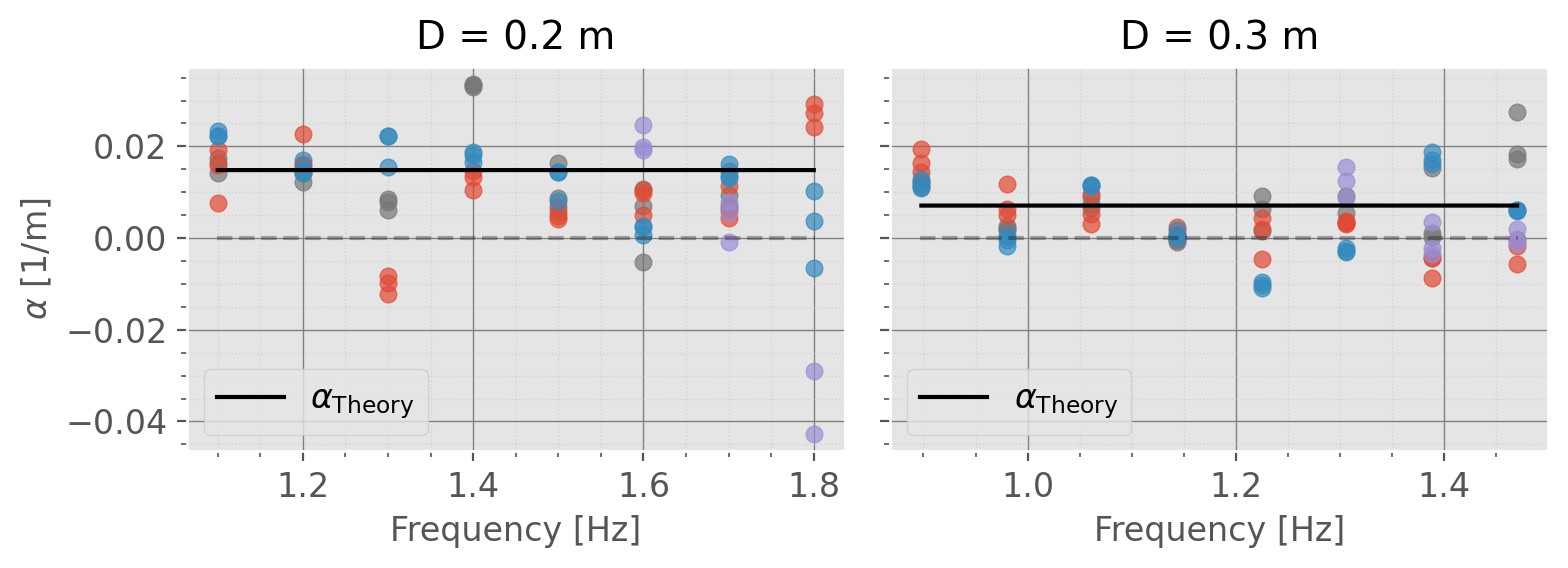

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}
ax[0].plot(f_20, np.array(a_theory_20), '-', color='black', label=r'$\alpha_{\text{Theory}}$')
ax[1].plot(f_30, np.array(a_theory_30), '-', color='black', label=r'$\alpha_{\text{Theory}}$')

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["alpha_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["alpha_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

""" ax[0].plot(plates_20['frequency'], plates_20['alpha_plates'], 'o', alpha=0.7, color='C0', label=r'$\alpha_{\text{Obs.}}$')
ax[1].plot(plates_30['frequency'], plates_30['alpha_plates'], 'o', alpha=0.7, color='C1', label=r'$\alpha_{\text{Obs.}}$')"""

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$\alpha$ [1/m]')

ax[0].legend(loc='lower left')
ax[1].legend(loc='lower left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/alpha_obs_vs_theory.png", dpi=300)

## For fun

In [17]:
2*np.pi/1

6.283185307179586

In [41]:
k = np.linspace(0.1, 10, 100)
l = 2*np.pi/k
kH = k*H_20

def get_f(k, H):
    """Calculate the frequency corresponding to a given wave number k and water depth H using the dispersion relation."""
    g = 9.81  # gravitational acceleration
    return np.sqrt(g * k * np.tanh(k * H)) / (2 * np.pi)
f_ex = get_f(k, H_20)

In [20]:
a_t = []
a_w = []

for k_i in k:
    t, w = spatial_damping_coefficient(k_i, D_20, H_20)
    a_t.append(t)
    a_w.append(w)

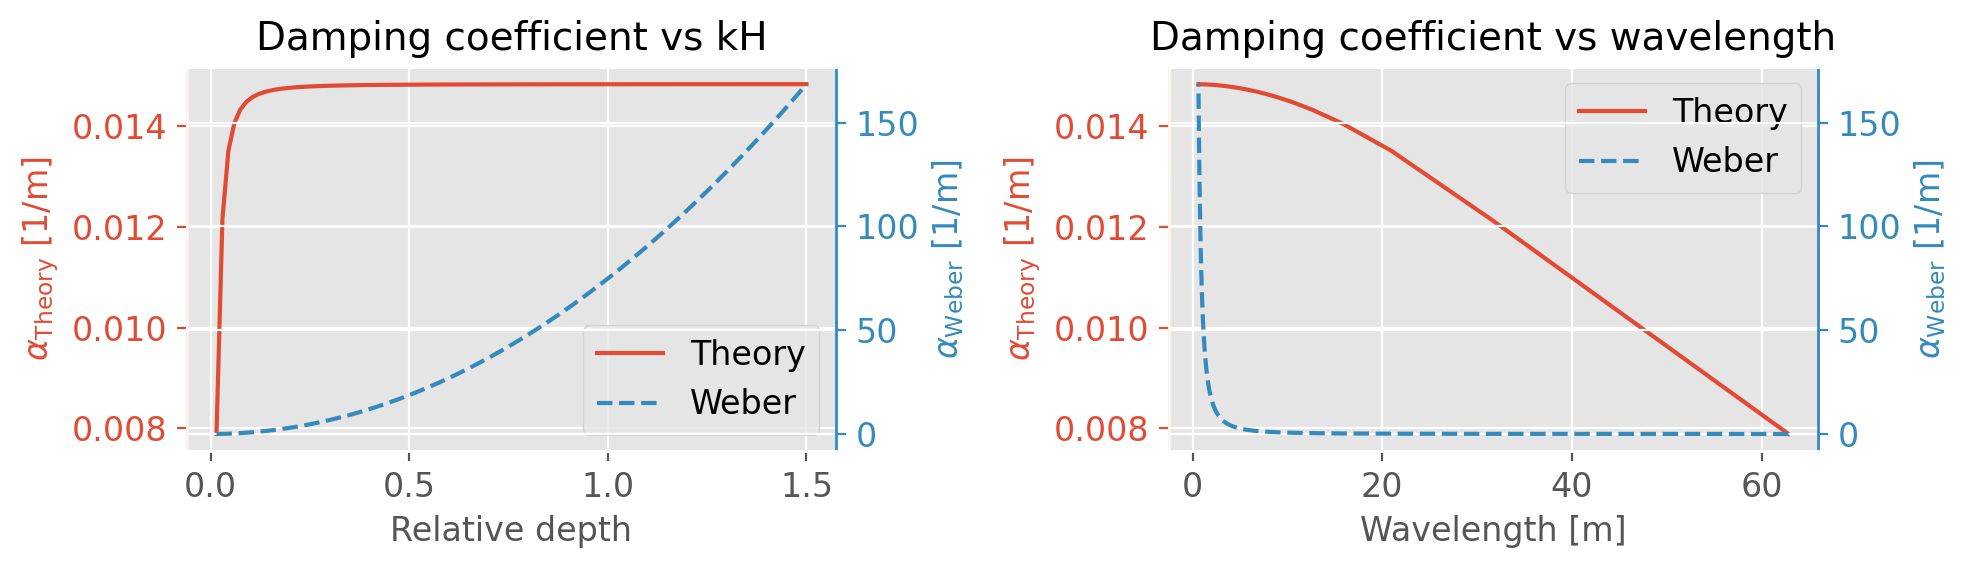

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

# Colors for consistency
color_theory = 'C0'
color_weber  = 'C1'

# --- Left subplot: vs kH ---
ax0 = ax[0]
ax0_weber = ax0.twinx()  # secondary y-axis for Weber

# Theory on primary y-axis
ax0.plot(kH, a_t, color=color_theory, label='Theory')

# Weber on secondary y-axis
ax0_weber.plot(kH, a_w, color=color_weber, linestyle='--', label='Weber')

ax0.set_xlabel('Relative depth')
ax0.set_ylabel(r'$\alpha_{\mathrm{Theory}}$ [1/m]', color=color_theory)
ax0_weber.set_ylabel(r'$\alpha_{\mathrm{Weber}}$ [1/m]', color=color_weber)
ax0.set_title('Damping coefficient vs kH')

# Color y-axis ticks and spine to match lines
ax0.tick_params(axis='y', colors=color_theory)
ax0.spines['left'].set_color(color_theory)

ax0_weber.tick_params(axis='y', colors=color_weber)
ax0_weber.spines['right'].set_color(color_weber)

# Combined legend for both axes
lines0, labels0 = ax0.get_legend_handles_labels()
lines0_w, labels0_w = ax0_weber.get_legend_handles_labels()
ax0.legend(lines0 + lines0_w, labels0 + labels0_w, loc='best')

# --- Right subplot: vs wavelength ---
ax1 = ax[1]
ax1_weber = ax1.twinx()  # secondary y-axis for Weber

# Theory on primary y-axis
ax1.plot(l, a_t, color=color_theory, label='Theory')

# Weber on secondary y-axis
ax1_weber.plot(l, a_w, color=color_weber, linestyle='--', label='Weber')

ax1.set_xlabel('Wavelength [m]')
ax1.set_ylabel(r'$\alpha_{\mathrm{Theory}}$ [1/m]', color=color_theory)
ax1_weber.set_ylabel(r'$\alpha_{\mathrm{Weber}}$ [1/m]', color=color_weber)
ax1.set_title('Damping coefficient vs wavelength')

# Color y-axis ticks and spine to match lines
ax1.tick_params(axis='y', colors=color_theory)
ax1.spines['left'].set_color(color_theory)

ax1_weber.tick_params(axis='y', colors=color_weber)
ax1_weber.spines['right'].set_color(color_weber)

# Combined legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines1_w, labels1_w = ax1_weber.get_legend_handles_labels()
ax1.legend(lines1 + lines1_w, labels1 + labels1_w, loc='best')

fig.tight_layout()

In [11]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_20.append(np.sqrt((val - a_theory_20[idx]) ** 2))
plates_20['rms_alpha'] = rms_20

rms_30 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_30.append(np.sqrt((val - a_theory_30[idx]) ** 2))
plates_30['rms_alpha'] = rms_30

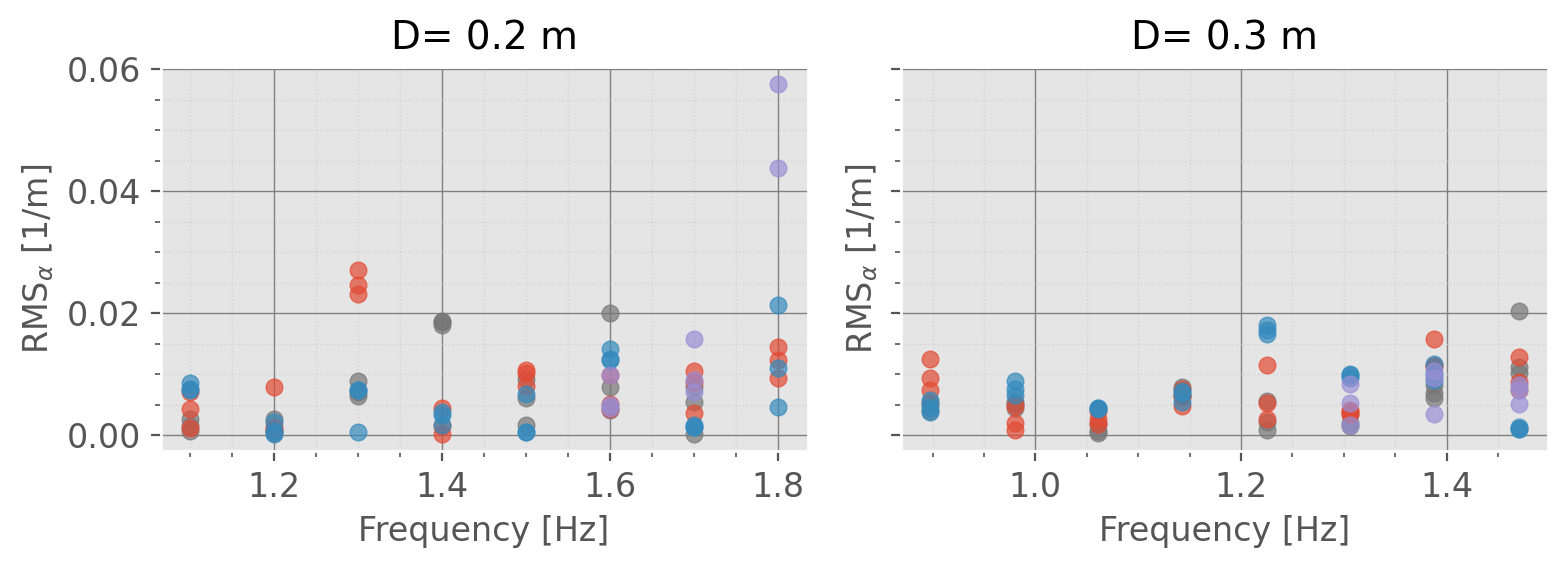

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["rms_alpha"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["rms_alpha"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))
    
ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_alpha_obs_vs_theory.png", dpi=300)

In [56]:
print(f"Mean RMS for D=0.2 m: {plates_20['rms_alpha'].mean():.4f} 1/m")
print(f"Mean RMS for D=0.3 m: {plates_30['rms_alpha'].mean():.4f} 1/m")

print(f"Max RMS for D=0.2 m: {plates_20['rms_alpha'].max():.4f} 1/m")
print(f"Max RMS for D=0.3 m: {plates_30['rms_alpha'].max():.4f} 1/m")

print(f"Min RMS for D=0.2 m: {plates_20['rms_alpha'].min():.4f} 1/m")
print(f"Min RMS for D=0.3 m: {plates_30['rms_alpha'].min():.4f} 1/m")

print(f"Median RMS for D=0.2 m: {plates_20['rms_alpha'].median():.4f} 1/m")
print(f"Median RMS for D=0.3 m: {plates_30['rms_alpha'].median():.4f} 1/m")

Mean RMS for D=0.2 m: 0.0084 1/m
Mean RMS for D=0.3 m: 0.0066 1/m
Max RMS for D=0.2 m: 0.0576 1/m
Max RMS for D=0.3 m: 0.0203 1/m
Min RMS for D=0.2 m: 0.0002 1/m
Min RMS for D=0.3 m: 0.0004 1/m
Median RMS for D=0.2 m: 0.0071 1/m
Median RMS for D=0.3 m: 0.0058 1/m


In [68]:
# Behold alle rader der frequency IKKE er 1.7 eller 1.8
pl_20 = plates_20[~plates_20["frequency"].isin([1.7, 1.8])]
pl_30 = plates_30[~plates_30["frequency"].isin([1.388, 1.470])]

print("Mean ratio of theory to observed damping (excluding the two highest frequencies):")
print(np.mean(a_theory_20[:-2]) / np.mean(pl_20['alpha_plates']))
print(np.mean(a_theory_30[:-2]) / np.mean(pl_30['alpha_plates']))

Mean ratio of theory to observed damping (excluding the two highest frequencies):
1.1516672534580283
1.471293406676955


In [13]:
R_theory_20_eq39 = []
R_theory_30_eq39 = []

for k in k_20:
    R_theory_20_eq39.append(robin_parameter_eq_39(H=H_20, a=a_theory_20[k_20.index(k)], k=k))

for k in k_30:
    R_theory_30_eq39.append(robin_parameter_eq_39(H=H_30, a=a_theory_30[k_30.index(k)], k=k))

In [14]:
R_theory_20_eq28 = []
R_theory_30_eq28 = []

for k, f in zip(k_20, f_20):
    R_theory_20_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_20[k_20.index(k)], H=H_20))

for k, f in zip(k_30, f_30):
    R_theory_30_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_30[k_30.index(k)], H=H_30))

In [15]:
"""
Subtract the wall-effects from the damping coefficients observed with plates, to get the damping due to the plates alone. 
Then compare this to the theoretical predictions for damping by a thin plate.
"""
plates_20['R_plates'] = plates_20['R'] - no_plates_20['R']
plates_30['R_plates'] = plates_30['R'] - no_plates_30['R']

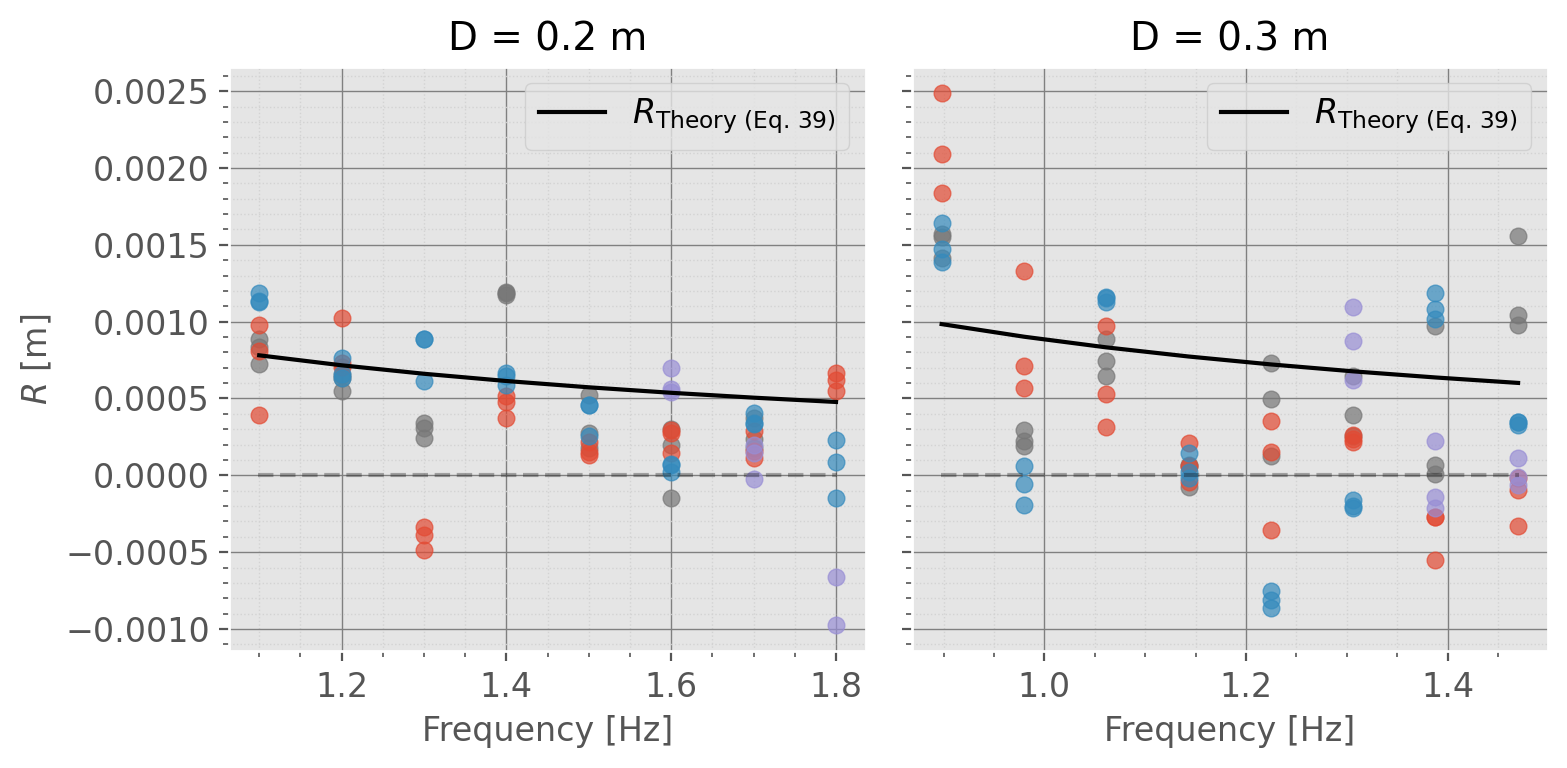

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["R_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["R_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].plot(f_20, R_theory_20_eq39, '-', color='black', label=r'$R_{\text{Theory (Eq. 39)}}$')
ax[1].plot(f_30, R_theory_30_eq39, '-', color='black', label=r'$R_{\text{Theory (Eq. 39)}}$')

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$R$ [m]')
ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory_eq39.png", dpi=300)

In [45]:
def add_R_eq28(df, H, D):
    R_eq28 = []
    for idx, row in df.iterrows():
        f = row['frequency']
        k = estimate_wavenumber(f, D)
        a = row['alpha']
        R_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a, H=H))
    df['R_eq28'] = R_eq28
    return df

In [46]:
plates_20 = add_R_eq28(plates_20, H_20, D_20)
plates_30 = add_R_eq28(plates_30, H_30, D_30)
no_plates_20 = add_R_eq28(no_plates_20, H_20, D_20)
no_plates_30 = add_R_eq28(no_plates_30, H_30, D_30)

In [47]:
plates_20['R_plates_28'] = plates_20['R_eq28'] - no_plates_20['R_eq28']
plates_30['R_plates_28'] = plates_30['R_eq28'] - no_plates_30['R_eq28']

In [48]:
kH20 = plates_20['kH'].unique()
kH30 = plates_30['kH'].unique()

In [49]:
kH20.min()

np.float64(1.1779062854958546)

In [71]:
print("Mean ratio of theory to observed Robin parameter (excluding the two highest frequencies):")
print(np.mean(R_theory_20_eq28[:-2]) / np.mean(pl_20['R_plates_28']))
print(np.mean(R_theory_30_eq28[:-2]) / np.mean(pl_30['R_plates_28']))


Mean ratio of theory to observed Robin parameter (excluding the two highest frequencies):
0.9318241314442781
1.0083033821516323


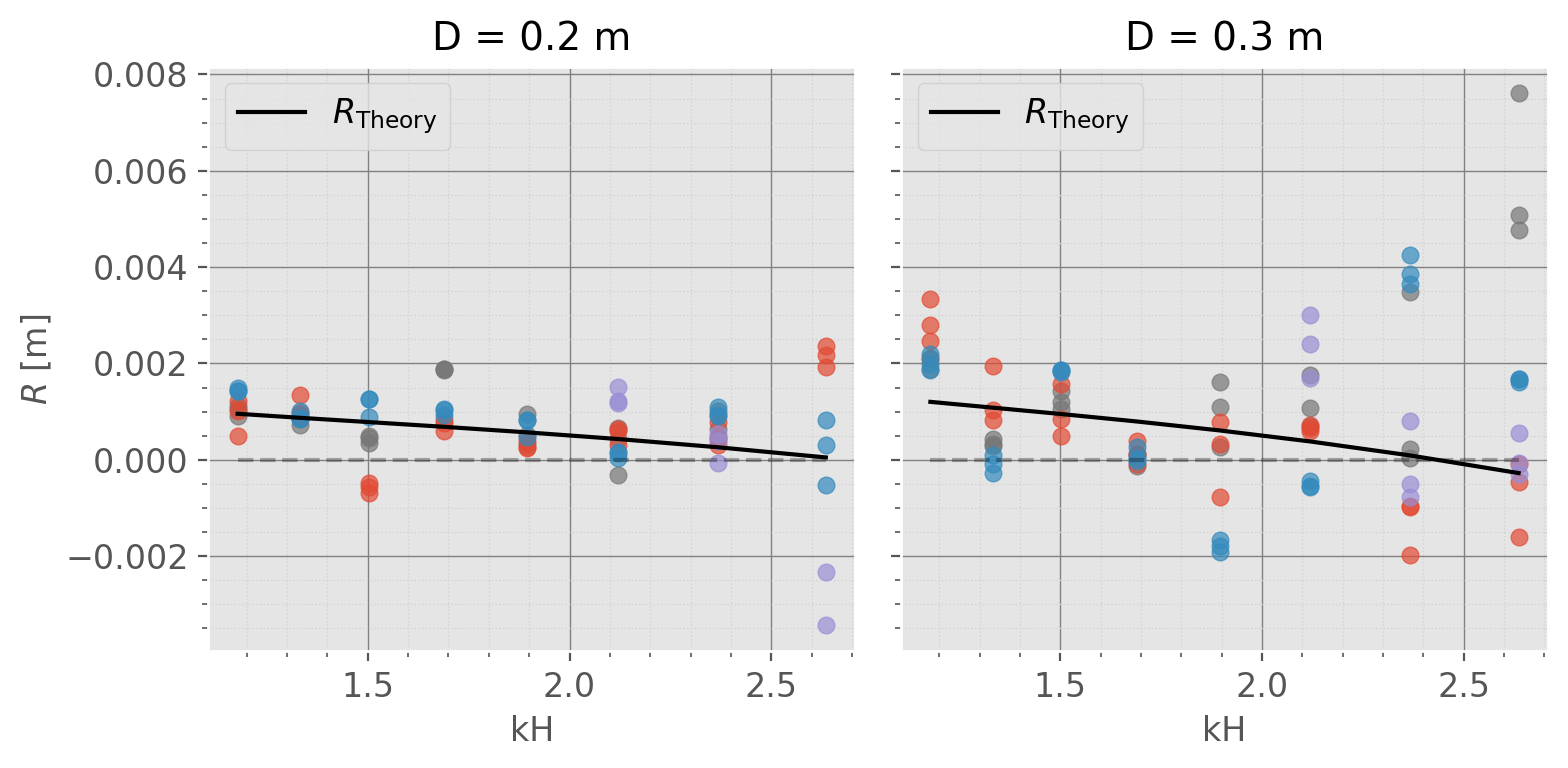

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["kH"], sub["R_plates_28"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["kH"], sub["R_plates_28"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].plot(kH20, R_theory_20_eq28, '-', color='black', label=r'$R_{\text{Theory}}$')
ax[1].plot(kH30, R_theory_30_eq28, '-', color='black', label=r'$R_{\text{Theory}}$')

ax[0].hlines(0, kH20.min(), kH20.max(), colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, kH30.min(), kH30.max(), colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('kH')
ax[1].set_xlabel('kH')
ax[0].set_ylabel(r'$R$ [m]')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory_eq28.png", dpi=300)

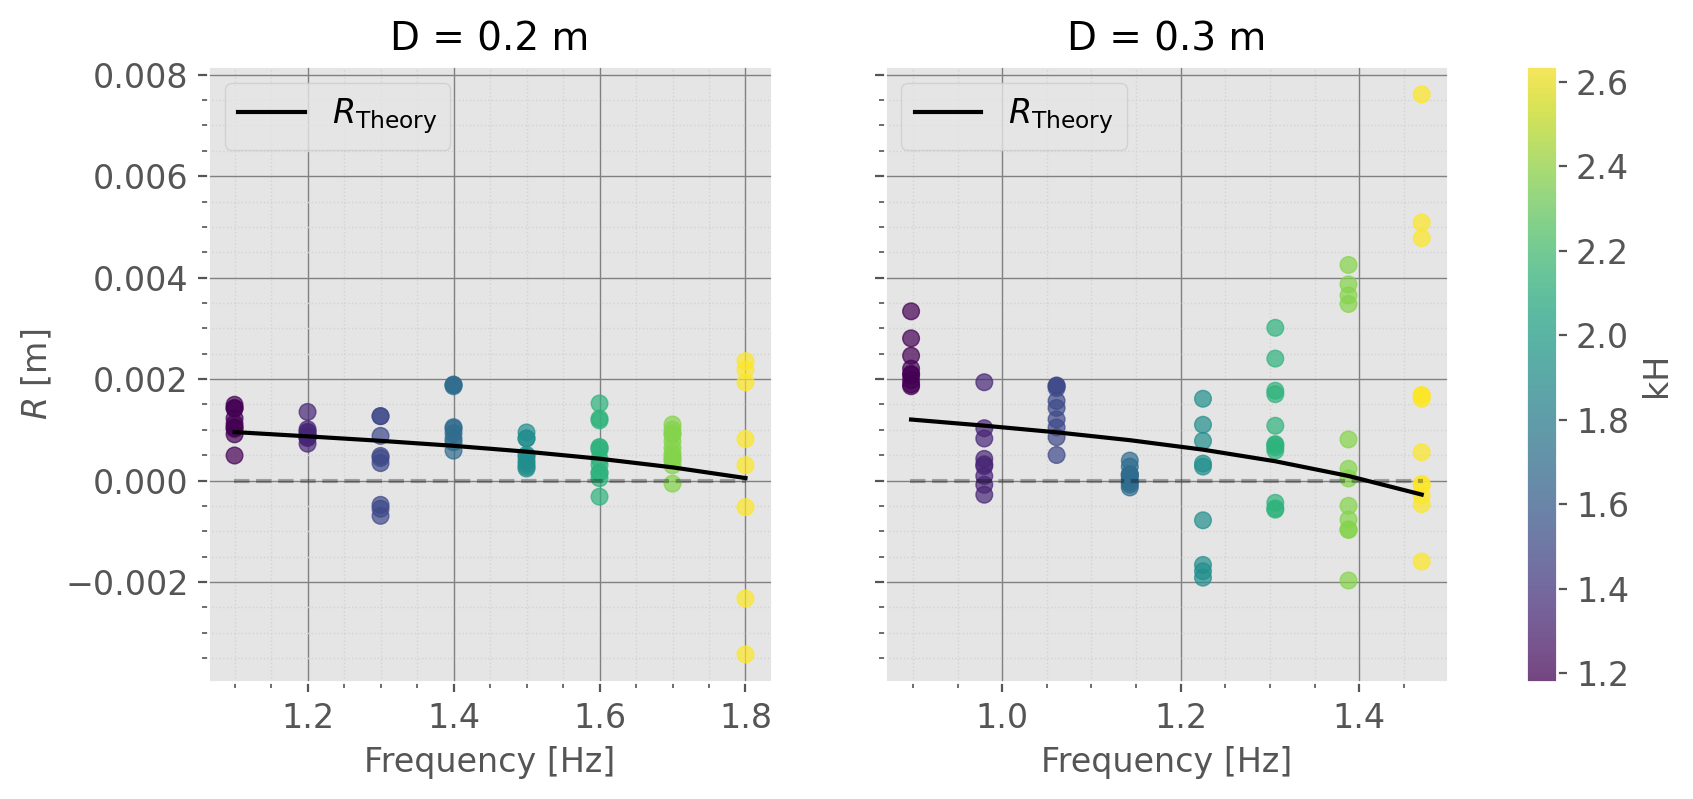

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Choose a colormap
cmap = "viridis"

# Get global min/max of kH to keep color scale consistent
kH_min = min(plates_20["kH"].min(), plates_30["kH"].min())
kH_max = max(plates_20["kH"].max(), plates_30["kH"].max())

for level, sub in plates_20.groupby("volt_level"):
    sc0 = ax[0].scatter(
        sub["frequency"],
        sub["R_plates_28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],          # color by kH
        cmap=cmap,
        vmin=kH_min, vmax=kH_max,
    )

for level, sub in plates_30.groupby("volt_level"):
    sc1 = ax[1].scatter(
        sub["frequency"],
        sub["R_plates_28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],          # color by kH
        cmap=cmap,
        vmin=kH_min, vmax=kH_max,
    )

ax[0].plot(f_20, R_theory_20_eq28, "-", color="black", label=r"$R_{\text{Theory}}$")
ax[1].plot(f_30, R_theory_30_eq28, "-", color="black", label=r"$R_{\text{Theory}}$")

ax[0].hlines(0, 1.099, 1.801, colors="k", linestyles="dashed", alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors="k", linestyles="dashed", alpha=0.3)

ax[0].set_title("D = 0.2 m")
ax[1].set_title("D = 0.3 m")

ax[0].set_xlabel("Frequency [Hz]")
ax[1].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel(r"$R$ [m]")
ax[0].legend(loc="upper left")
ax[1].legend(loc="upper left")

for a in ax:
    a.minorticks_on()
    a.grid(which="major", linestyle="-", linewidth="0.5", color="gray")
    a.grid(which="minor", linestyle=":", linewidth="0.5", color="lightgray")

# Add a single colorbar for kH
cbar = fig.colorbar(sc0, ax=ax, label="kH")

plt.savefig(
    "/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory_eq28.png",
    dpi=300,
)

In [52]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20_eq39 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_20_eq39.append(np.sqrt((val - R_theory_20_eq39[idx]) ** 2))
plates_20['rms_R_eq39'] = rms_20_eq39

rms_30_eq39 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'R_plates'].values
    for val in obs:
        rms_30_eq39.append(np.sqrt((val - R_theory_30_eq39[idx]) ** 2))
plates_30['rms_R_eq39'] = rms_30_eq39

In [53]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20_eq28 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'R_plates_28'].values
    for val in obs:
        rms_20_eq28.append(np.sqrt((val - R_theory_20_eq28[idx]) ** 2))
plates_20['rms_R_eq28'] = rms_20_eq28

rms_30_eq28 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'R_plates_28'].values
    for val in obs:
        rms_30_eq28.append(np.sqrt((val - R_theory_30_eq28[idx]) ** 2))
plates_30['rms_R_eq28'] = rms_30_eq28

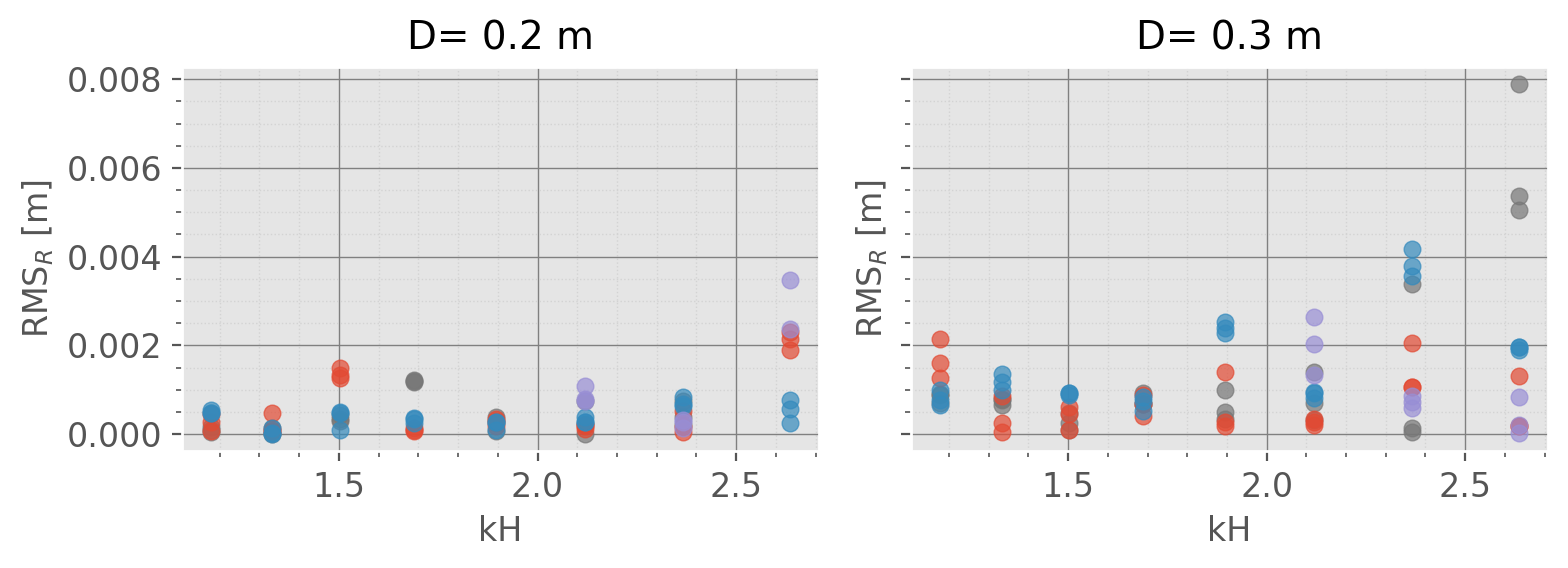

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["kH"], sub["rms_R_eq28"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["kH"], sub["rms_R_eq28"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))
    
ax[0].set_xlabel('kH')
ax[0].set_ylabel(r'RMS$_{R}$ [m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('kH')
ax[1].set_ylabel(r'RMS$_{R}$ [m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq28.png", dpi=300)

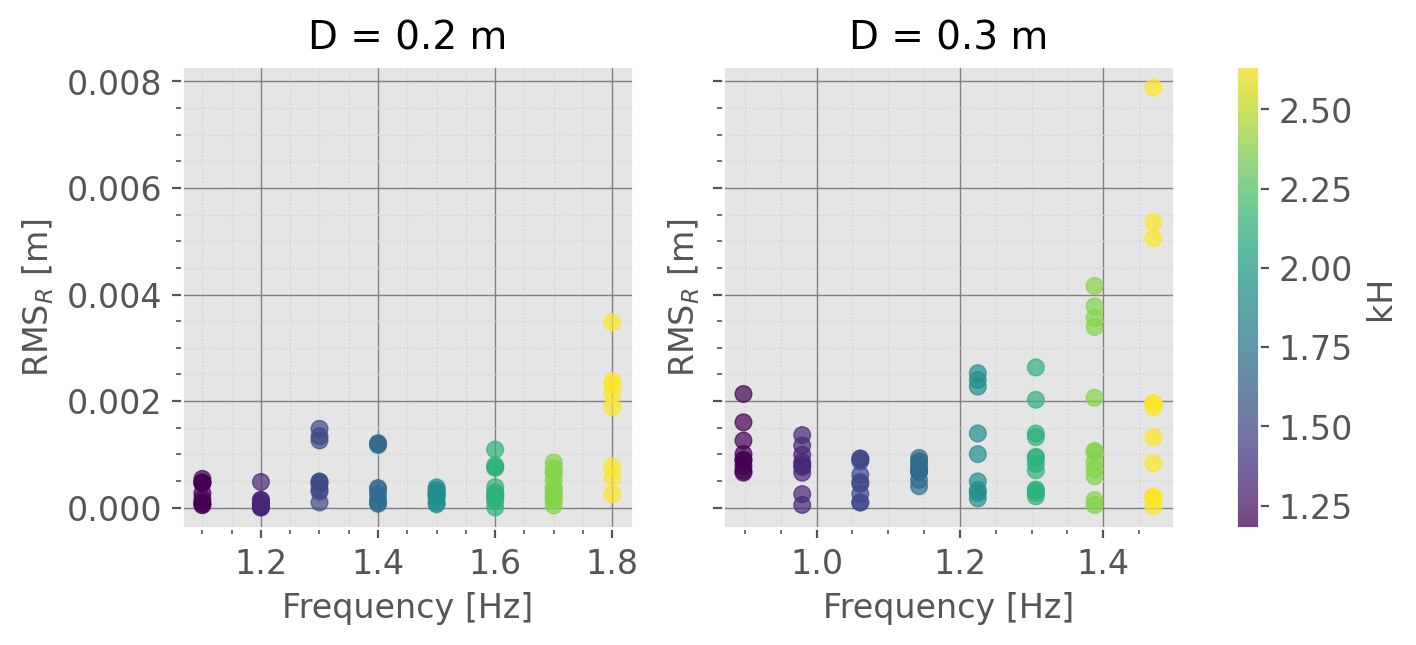

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Colormap and shared limits for kH
cmap = "viridis"
kH_min = min(plates_20["kH"].min(), plates_30["kH"].min())
kH_max = max(plates_20["kH"].max(), plates_30["kH"].max())

# Left panel: D = 0.2 m
for level, sub in plates_20.groupby("volt_level"):
    sc0 = ax[0].scatter(
        sub["frequency"],
        sub["rms_R_eq28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],
        cmap=cmap,
        vmin=kH_min,
        vmax=kH_max,
        label=f"{level}",   # volt_level in legend
    )

# Right panel: D = 0.3 m
for level, sub in plates_30.groupby("volt_level"):
    sc1 = ax[1].scatter(
        sub["frequency"],
        sub["rms_R_eq28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],
        cmap=cmap,
        vmin=kH_min,
        vmax=kH_max,
    )

ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel(r"RMS$_{R}$ [m]")
ax[0].set_title("D = 0.2 m")

ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel(r"RMS$_{R}$ [m]")
ax[1].set_title("D = 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which="major", linestyle="-", linewidth="0.5", color="gray")
    a.grid(which="minor", linestyle=":", linewidth="0.5", color="lightgray")

# Shared colorbar for kH
cbar = fig.colorbar(sc0, ax=ax, label="kH")

plt.savefig(
    "/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq28.png",
    dpi=300,
)
